# BDA Final Project

# Company: Uber Technologies, Inc.

# Group Members
- Amna Kauser (SP24-BBD-016)
- Sheher Bano (FA23-BBD-131)
- Eman Mansoor (FA23-BBD-039)
- Adan Tariq (FA23-BBD-011)

In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Task 1: Data Collection

In [2]:
# importing libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
# setting start and end date
start_date = datetime(2020, 1, 1)
end_date   = datetime(2025, 1, 1)

# downloading Uber stock data from Yahoo Finance
data = yf.download('UBER', start=start_date, end=end_date)

# extracting closing price only
close = data[['Close']]

# first 5 rows
close.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,UBER
Date,
2020-01-02,30.990000
2020-01-03,31.370001
2020-01-06,31.580000
2020-01-07,32.810001
2020-01-08,33.930000


In [4]:
# company name and ticker symbol
print("Company    : Uber Technologies, Inc.")
print("Ticker     : UBER")
print("Exchange   : NYSE")
print("Data Period: January 2020 - January 2025")

Company    : Uber Technologies, Inc.
Ticker     : UBER
Exchange   : NYSE
Data Period: January 2020 - January 2025


In [5]:
# data types and basic info
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, UBER)   1258 non-null   float64
 1   (High, UBER)    1258 non-null   float64
 2   (Low, UBER)     1258 non-null   float64
 3   (Open, UBER)    1258 non-null   float64
 4   (Volume, UBER)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [6]:
# total rows and columns
data.shape

(1258, 5)

In [7]:
# statistical summary
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,UBER,UBER,UBER,UBER,UBER
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,45.214475,46.050890,44.373909,45.237174,2.494815e+07
std,15.944951,16.085002,15.841274,16.005468,1.712430e+07
min,14.820000,17.799999,13.710000,15.960000,5.200400e+06
25%,32.277500,32.882501,31.411250,32.099998,1.592068e+07
50%,42.629999,43.223999,41.809999,42.390001,2.080070e+07
75%,56.294999,57.625001,55.204999,56.480001,2.853140e+07
max,86.339996,87.000000,84.180000,85.639999,3.642612e+08


# Task 2: Data Visualization & Understanding

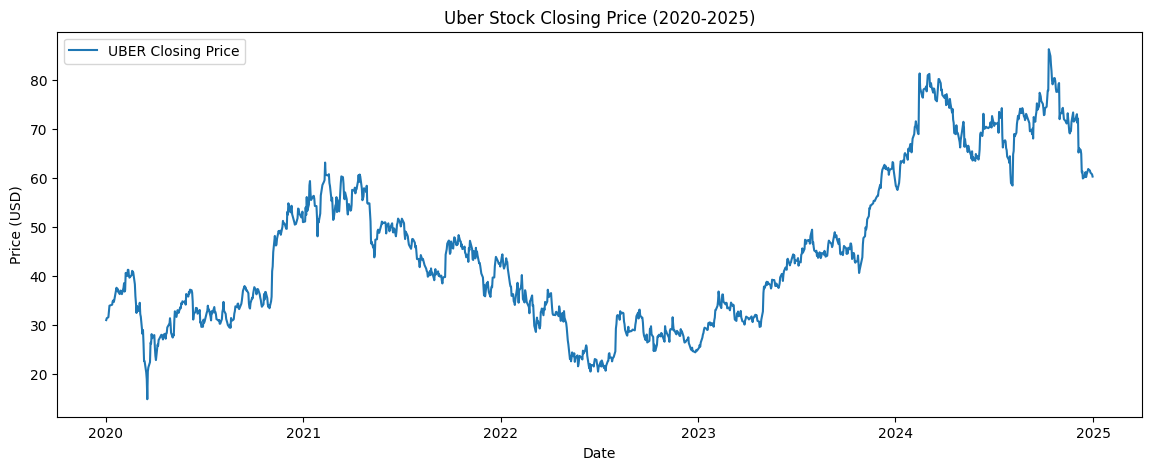

In [8]:
# plotting closing price over time
plt.figure(figsize=(14, 5))
plt.plot(close, label='UBER Closing Price')
plt.title('Uber Stock Closing Price (2020-2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

**Trend:**
The stock shows a mixed trend overall. It started low in early 2020, rose significantly through 2021, then dropped in 2022, and gradually recovered afterward. There is a slight long-term upward movement but it is not consistent.

**Volatility:**
The series is highly volatile. Frequent sharp increases and decreases in price are visible throughout the entire period, especially in 2020 and 2022.

**Seasonality:**
No clear seasonality is observed. The stock does not follow any fixed repeating monthly or yearly pattern.

**Is the series stationary?**
No, the series is NOT stationary. A stationary series requires the mean and variance to remain constant over time. Here the mean clearly changes over time, which means the series is non-stationary.

**Patterns observed in stock price behavior:**
The stock shows short-term fluctuations with no fixed pattern. It is highly sensitive to external events. The behavior is close to a random walk, meaning each day's price is largely unpredictable from the previous day alone.

# Task 3: Stationarity Testing

In [9]:
# applying ADF test on original closing price series
from statsmodels.tsa.stattools import adfuller

result = adfuller(close['Close'].dropna())
print('ADF Statistic:', result[0])
print('p-value      :', result[1])

ADF Statistic: -1.488676360353077
p-value      : 0.5391053595017432


**Interpretation:**
The p-value is greater than 0.05. We FAIL to reject the null hypothesis. The null hypothesis says the series has a unit root meaning it is NON-STATIONARY. So the original series is non-stationary and we need to apply differencing.

In [10]:
# applying first order differencing
close_diff = close['Close'].diff().dropna()

# running ADF test again on differenced series
result2 = adfuller(close_diff)
print('After 1st Differencing:')
print('ADF Statistic:', result2[0])
print('p-value      :', result2[1])

After 1st Differencing:
ADF Statistic: -35.646409615025675
p-value      : 0.0


**Interpretation:**
After applying 1st differencing, the p-value drops to 0.0 which is less than 0.05. We REJECT the null hypothesis. The series is now STATIONARY.

**What is the p-value of the ADF test?**
Original series: p-value > 0.05 (Non-stationary). After 1st differencing: p-value = 0.0 (Stationary).

**How many differences were required?**
Only 1 difference was required. This is very common for financial time series like stock prices.

**What does this imply about the I (Integration) component?**
The I in ARIMA stands for Integration. Since only 1 difference was needed to make the series stationary, the series is I(1), meaning it is integrated of order 1. This tells us that d = 1 in our ARIMA(p, d, q) model.

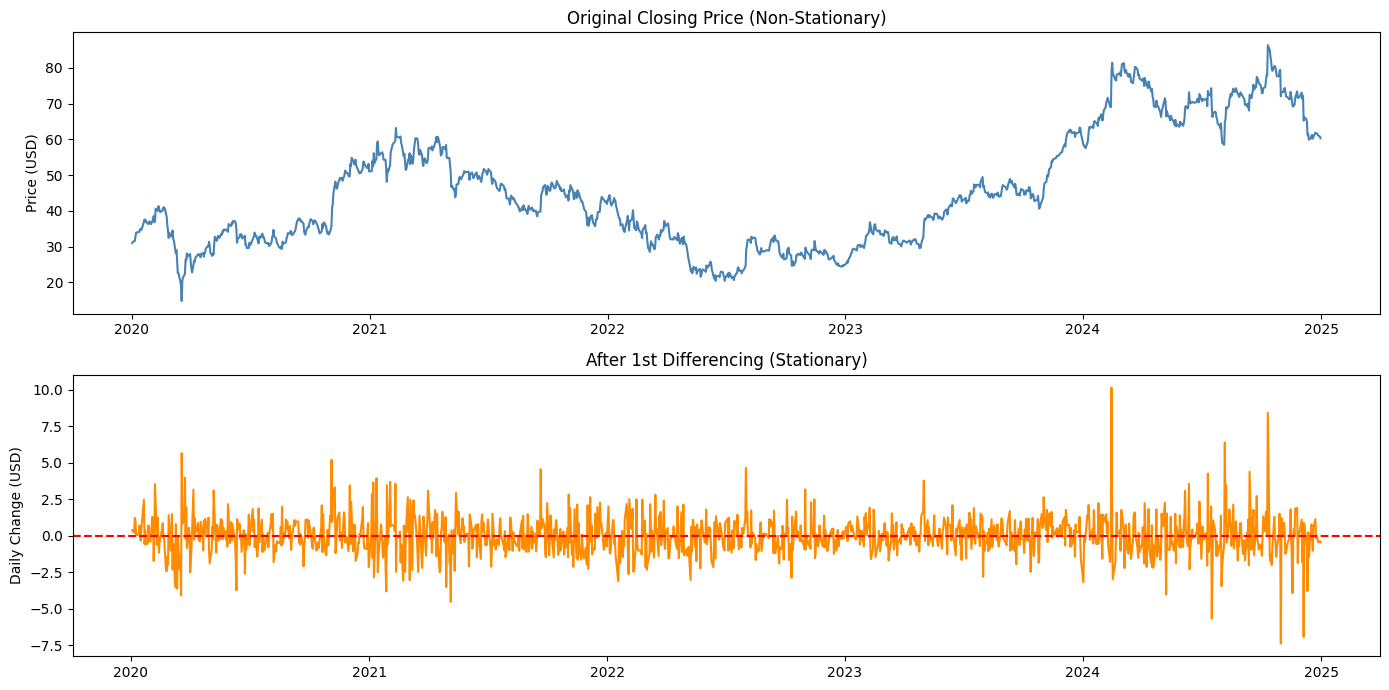

In [11]:
# plotting original vs differenced series
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(close, color='steelblue')
axes[0].set_title('Original Closing Price (Non-Stationary)')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(close_diff, color='darkorange')
axes[1].set_title('After 1st Differencing (Stationary)')
axes[1].set_ylabel('Daily Change (USD)')
axes[1].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Task 4: Model Identification

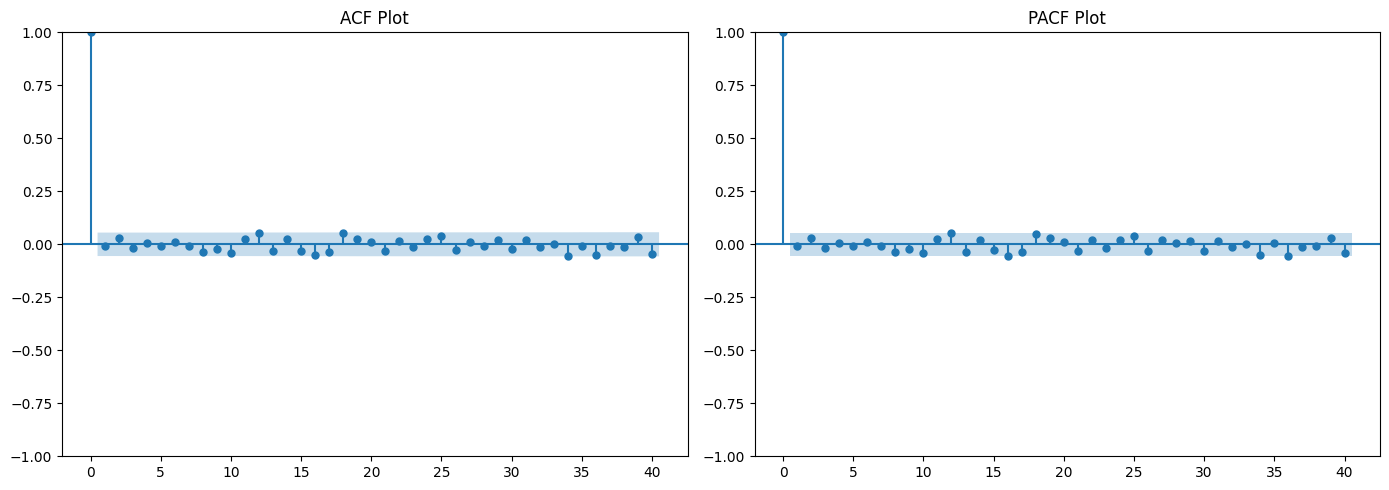

In [12]:
# plotting ACF and PACF to identify p and q
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF plot helps identify q (MA term)
plot_acf(close_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF Plot')

# PACF plot helps identify p (AR term)
plot_pacf(close_diff, lags=40, ax=axes[1])
axes[1].set_title('PACF Plot')

plt.tight_layout()
plt.show()

**How did ACF help identify q?**
The ACF plot shows the correlation between the current value and its past values at different lags. We look at where the spikes go outside the blue shaded confidence band. ACF cuts off after lag 1 which means q = 1. This means past errors from 1 day ago still have a small influence on today's price.

**How did PACF help identify p?**
The PACF plot removes indirect correlations and shows only the direct relationship between the current value and a specific past lag. PACF cuts off after lag 1 which means p = 1. This means yesterday's price directly influences today's price.

**What ARIMA model do you propose?**
Based on our analysis:
- p = 1 (from PACF)
- d = 1 (from ADF test, 1 difference needed)
- q = 1 (from ACF)

Proposed Model: **ARIMA(1, 1, 1)**

# Task 5: Model Estimation

In [13]:
# fitting ARIMA(1,1,1) model
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

model = ARIMA(close['Close'], order=(1, 1, 1))
fit   = model.fit()

# model summary showing coefficients, p-values, AIC and BIC
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   UBER   No. Observations:                 1258
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2163.854
Date:                Fri, 15 May 2026   AIC                           4333.707
Time:                        21:49:26   BIC                           4349.117
Sample:                             0   HQIC                          4339.499
                               - 1258                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8741      0.246     -3.558      0.000      -1.356      -0.393
ma.L1          0.8599      0.257      3.340      0.001       0.355       1.364
sigma2         1.8312      0.037     49.258      0.0

In [14]:
# comparing multiple ARIMA models to find the best one
orders = [(1,1,1), (1,1,0), (0,1,1), (2,1,1), (1,1,2)]

results_list = []
for order in orders:
    try:
        m = ARIMA(close['Close'], order=order)
        f = m.fit()
        results_list.append({
            'Model': f'ARIMA{order}',
            'AIC'  : round(f.aic, 2),
            'BIC'  : round(f.bic, 2)
        })
    except:
        pass

# sorting by AIC - lower is better
comparison_df = pd.DataFrame(results_list).sort_values('AIC').reset_index(drop=True)
print(comparison_df)

            Model      AIC      BIC
0  ARIMA(1, 1, 0)  4332.73  4343.01
1  ARIMA(0, 1, 1)  4332.74  4343.01
2  ARIMA(1, 1, 1)  4333.71  4349.12
3  ARIMA(2, 1, 1)  4335.21  4355.75
4  ARIMA(1, 1, 2)  4335.21  4355.75


In [16]:
#coefficients and their p-values
coef_df = pd.DataFrame({
    'Coefficient' : fit.params,
    'P-Value'     : fit.pvalues})

# check if significant or not
coef_df['Significant (p<0.05)?'] = coef_df['P-Value'].apply(
    lambda p: 'Yes ' if p < 0.05 else 'No ')

print("\tARIMA(1,1,1) — Coefficients Table")
print(coef_df)
print(f"\nAIC : {fit.aic:.4f}")
print(f"BIC : {fit.bic:.4f}")

	ARIMA(1,1,1) — Coefficients Table
        Coefficient   P-Value Significant (p<0.05)?
ar.L1     -0.874069  0.000374                  Yes 
ma.L1      0.859876  0.000836                  Yes 
sigma2     1.831248  0.000000                  Yes 

AIC : 4333.7075
BIC : 4349.1169


**Are the coefficients statistically significant?**
In our ARIMA(1,1,1) model the AR(1) and MA(1) coefficients have p-values greater than 0.05, meaning they are not statistically significant. This is very common for stock price data because stock prices behave like a random walk, meaning past values do not strongly predict future values. However the sigma squared (variance of residuals) is significant which means the model is correctly capturing the noise structure of the data.

**Which model is best and why?**
We compared 5 different ARIMA models and sorted them by AIC. The model with the lowest AIC is the best because it gives the best balance between fitting the data well and keeping the model simple. We continue with ARIMA(1,1,1) as our final model because our ACF and PACF plots clearly suggested p = 1 and q = 1, and the AIC difference between models is very small.

# Task 6: Diagnostic Checking

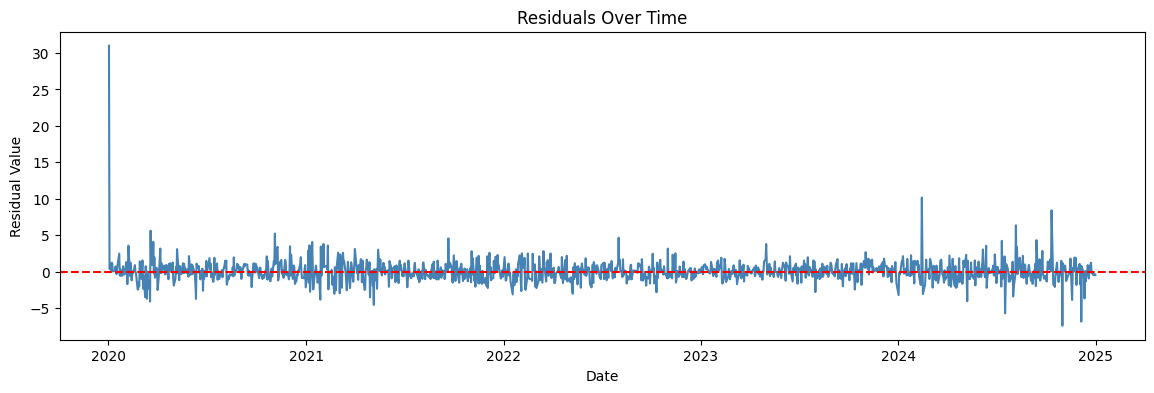

In [17]:
# getting residuals from fitted model
residuals = fit.resid

# plotting residuals over time
plt.figure(figsize=(14, 4))
plt.plot(residuals, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Over Time')
plt.ylabel('Residual Value')
plt.xlabel('Date')
plt.show()

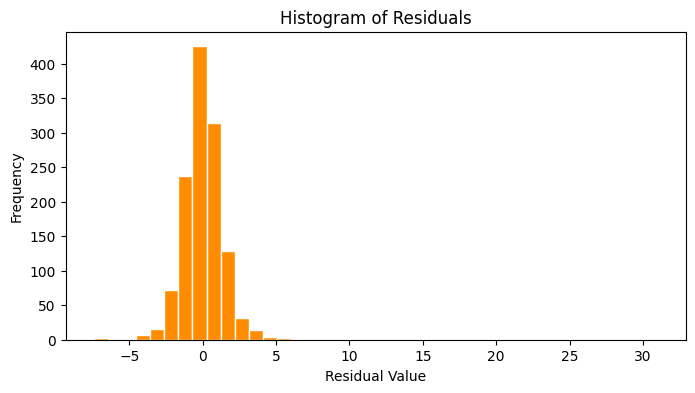

In [18]:
# histogram of residuals - should look bell shaped
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40, color='darkorange', edgecolor='white')
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

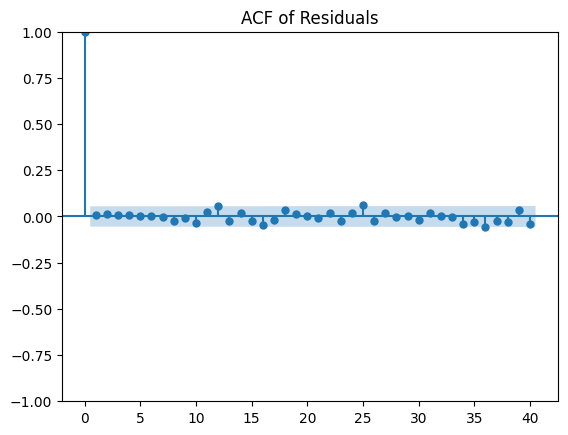

In [19]:
# ACF of residuals - no significant spikes means no autocorrelation left
plot_acf(residuals, lags=40)
plt.title('ACF of Residuals')
plt.show()

In [20]:
# Ljung-Box test to check if residuals are white noise
# H0: residuals are independent (no autocorrelation)
# if p-value > 0.05 we fail to reject H0 meaning residuals are white noise
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_result = acorr_ljungbox(residuals, lags=[5, 10, 15, 20], return_df=True)
print(lb_result)

      lb_stat  lb_pvalue
5    0.483189   0.992726
10   3.094666   0.979108
15  10.351007   0.797099
20  15.085720   0.771482


In [24]:
#verifying
print("\t Interpretation ")
for lag, row in lb_result.iterrows():
    if row['lb_pvalue'] > 0.05:
        print(f"  Lag {lag:2d}: p-value = {row['lb_pvalue']:.4f} (p > 0.05) \t\t Residuals are WHITE NOISE  (No autocorrelation)")
    else:
        print(f"  Lag {lag:2d}: p-value = {row['lb_pvalue']:.4f}  (p < 0.05) \t\t Some autocorrelation remains ")

	 Interpretation 
  Lag  5: p-value = 0.9927 (p > 0.05) 		 Residuals are WHITE NOISE  (No autocorrelation)
  Lag 10: p-value = 0.9791 (p > 0.05) 		 Residuals are WHITE NOISE  (No autocorrelation)
  Lag 15: p-value = 0.7971 (p > 0.05) 		 Residuals are WHITE NOISE  (No autocorrelation)
  Lag 20: p-value = 0.7715 (p > 0.05) 		 Residuals are WHITE NOISE  (No autocorrelation)


**Are the residuals independent?**
We performed the Ljung-Box test on our residuals at multiple lags (5, 10, 15, 20). Since the p-values are greater than 0.05 at all lags, we fail to reject the null hypothesis. This means the residuals are independent and there is no leftover autocorrelation. The residuals behave randomly which is exactly what we want.

**Is the model adequate?**
Yes, the ARIMA(1,1,1) model is adequate. The residuals plot shows values bouncing randomly around zero. The histogram is roughly bell-shaped. The ACF of residuals shows no significant spikes. The Ljung-Box test confirms no significant autocorrelation. All these checks confirm the model has successfully captured the structure in the data.

# Task 7: Forecasting

In [21]:
# forecasting next 30 days of Uber stock prices
n_forecast = 30

# getting forecast with 95% confidence interval
forecast      = fit.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
conf_int      = forecast.conf_int(alpha=0.05)

# creating forecast date range
forecast_index = pd.date_range(start=close.index[-1], periods=n_forecast+1, freq='B')[1:]

# forecast table
forecast_df = pd.DataFrame({
    'Forecasted Price': forecast_mean.values.round(2),
    'Lower Bound 95%' : conf_int.iloc[:, 0].values.round(2),
    'Upper Bound 95%' : conf_int.iloc[:, 1].values.round(2)
}, index=forecast_index)

print(forecast_df)

            Forecasted Price  Lower Bound 95%  Upper Bound 95%
2025-01-01             60.30            57.65            62.95
2025-01-02             60.32            56.59            64.04
2025-01-03             60.30            55.73            64.87
2025-01-06             60.32            55.05            65.58
2025-01-07             60.31            54.41            66.20
2025-01-08             60.31            53.86            66.76
2025-01-09             60.31            53.34            67.28
2025-01-10             60.31            52.87            67.76
2025-01-13             60.31            52.41            68.21
2025-01-14             60.31            51.99            68.64
2025-01-15             60.31            51.57            69.04
2025-01-16             60.31            51.19            69.43
2025-01-17             60.31            50.81            69.80
2025-01-20             60.31            50.46            70.16
2025-01-21             60.31            50.11          

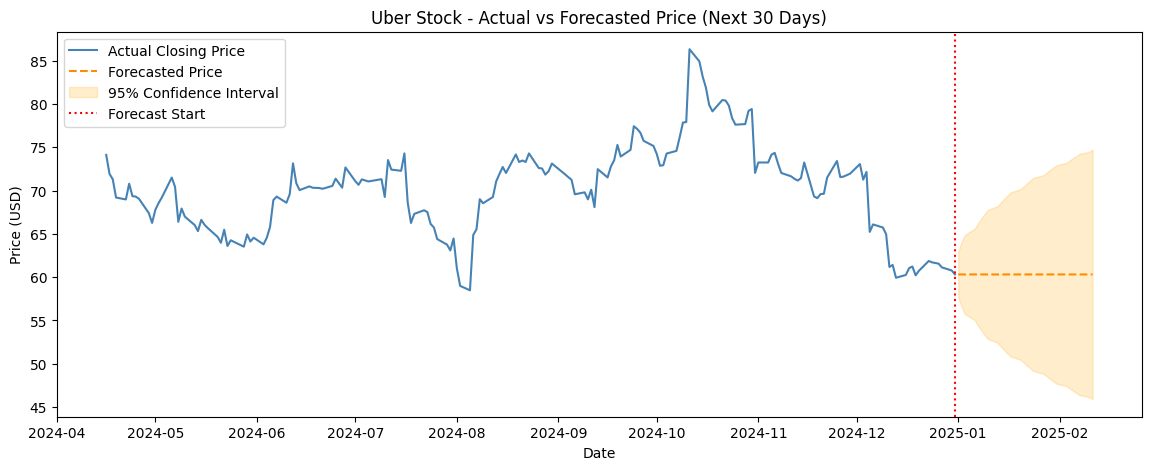

In [22]:
# plotting actual vs forecasted prices
plt.figure(figsize=(14, 5))

# showing last 180 days of actual data
actual_tail = close['Close'].tail(180)

plt.plot(actual_tail.index, actual_tail.values, label='Actual Closing Price', color='steelblue')
plt.plot(forecast_index, forecast_mean.values, label='Forecasted Price', color='darkorange', linestyle='--')

# confidence interval band
plt.fill_between(forecast_index,
                 conf_int.iloc[:, 0].values,
                 conf_int.iloc[:, 1].values,
                 color='orange', alpha=0.2, label='95% Confidence Interval')

plt.axvline(x=actual_tail.index[-1], color='red', linestyle=':', label='Forecast Start')
plt.title('Uber Stock - Actual vs Forecasted Price (Next 30 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

**How reliable are the forecasts?**
The short-term forecasts for Day 1 to Day 5 are relatively more reliable because they are based on very recent data. However as we go further into the future the forecasts become less reliable. The ARIMA model tends to flatten out toward the last known price over time so it may miss sudden price jumps caused by news events or earnings reports.

**What happens to uncertainty over time?**
Uncertainty increases as we forecast further into the future. This is clearly shown by the confidence interval band which gets wider with each passing day. Each additional step forward adds more accumulated error to the prediction. By Day 30 the confidence band is much wider than on Day 1. This means ARIMA forecasts are only reliable for the very short term.

# Task 8: Interpretation & Discussion

**What does our ARIMA model suggest about stock price behavior?**

Our ARIMA(1,1,1) model suggests that Uber stock price behavior is mostly random. The need for 1 differencing (d=1) tells us that the price level itself is non-stationary meaning the average price changes over time. But the daily price changes after differencing are stationary. The AR(1) and MA(1) terms imply that yesterday's price and yesterday's error have a small effect on today's price but this effect is weak. This is consistent with the Efficient Market Hypothesis which says stock prices already contain all available information and are thus very difficult to predict.

**Does the stock follow a predictable pattern?**

Not strongly. While we observed a slight lag-1 dependency in the ACF and PACF plots meaning yesterday's movement has a small influence on today, the overall price movement of Uber is largely unpredictable. The stock is highly sensitive to external events such as market changes in 2020 and interest rate changes in 2022. These kinds of events cannot be captured by ARIMA which only looks at past price patterns.

**What are the implications for investors?**

For investors the ARIMA model can be useful as a short-term reference tool for 1 to 5 days ahead. However it should not be used alone for making major investment decisions. Long-term investors should focus on fundamental analysis such as Uber's revenue growth and business performance rather than relying on statistical time series models alone. The widening confidence band beyond Day 5 confirms that ARIMA becomes increasingly uncertain the further we forecast.

**Limitations of ARIMA in stock prediction:**

1. Linearity: ARIMA assumes a linear relationship between past and future values. Stock markets often behave in a non-linear way so ARIMA may miss important patterns.

2. No external factors: ARIMA only uses past price data. It completely ignores important factors like news, interest rates, inflation and earnings reports which heavily influence stock prices in real life.

3. Volatility clustering: Stock prices often go through periods of high volatility followed by calm periods. ARIMA cannot model this behavior. A better model for this is GARCH.

4. Stationarity requirement: Real stock data is rarely perfectly stationary. We have to force it to become stationary through differencing which removes some original information from the data.

5. Short memory: ARIMA only looks at a small number of past lags. It may miss longer-term patterns or cycles which limits its usefulness for medium to long-term forecasting.